In [1]:
#%%
print('Importing relevant modules ...')
import warnings
warnings.filterwarnings('ignore',category=RuntimeWarning)
import os
import numpy as np
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pylab import rcParams
import matplotlib
from matplotlib import rc;rc('text', usetex=True);rc('font', weight='bold');matplotlib.rcParams['text.latex.preamble'] = r'\boldmath'
rcParams['font.family'] = 'serif'
rc('text.latex',preamble=r'\usepackage{/Users/kevinlevy/Documents/cluster_lensing/files/apjfonts}')
from mpl_toolkits.axes_grid1 import make_axes_locatable
color_arr = ['olivedrab', 'steelblue', 'goldenrod', 'indianred', 'lightseagreen']

import cosmo
import lensing
import lensing_estimator
import mockobs
import stats
import utils

Importing relevant modules ...


In [2]:
print('Defining relevant parameters ...')
nber_clus = 2500
nber_rand = 50000
cutout_size_am = 6
cutout_size_for_grad_est_am = 6
l_cut = 2000
average = 1
average_run = 1
nber_runs = 20
nx = 120
ny = 120
dx = 0.5
dy = 0.5
reso_arcmin = 0.5
map_params = [nx, dx, ny, dy]
beam_fwhm = 1.0 # arcmin
noiseval_white = 2.0 # uK-arcmin
l = np.arange(10001)
cl = cosmo.cmb_power_spectra(l)['TT']
bl = mockobs.beam_power_spectrum(beam_fwhm, l)
nl = mockobs.instrumental_noise_power_spectrum(noiseval_white, l)
cl_noise = mockobs.instrumental_noise_power_spectrum(noiseval_white, l, beam_fwhm)
z = 0.7
mass_reso = 0.01
mass_min = 0.0
mass_max = 6.0
mass_int = np.arange(mass_min, mass_max, mass_reso)
M_input = 1.47e14

# for plotting
xmin, xmax = -nx*reso_arcmin/2, nx*reso_arcmin/2
ymin, ymax = -ny*reso_arcmin/2, ny*reso_arcmin/2 
extent_arcmin = [xmin, xmax, ymin, ymax]
extent_degrees = np.asarray(extent_arcmin)/60
fontsize = 19
labelsize = 16

    
save_loc_results = '/Users/kevinlevy/Documents/cluster_lensing/results/foreground_bias'
if not os.path.exists(save_loc_results):
    os.makedirs(save_loc_results)

Defining relevant parameters ...


In [3]:
print('Checking likelhihood curves ...')
L_arr_sorted = np.load(save_loc_results+'/likelihoods.npy', allow_pickle=True)
L_ip_arr_sorted = np.load(save_loc_results+'/likelihoods_finer.npy', allow_pickle=True)
nber_runs = 13
s,e = 0, 13
print(len(L_arr_sorted[0]))
L_arr_sorted = [L_arr_sorted[0][s:e], L_arr_sorted[1][s:e], L_arr_sorted[2][s:e], L_arr_sorted[3][s:e], 
                L_arr_sorted[4][s:e], L_arr_sorted[5][s:e]]
print(len(L_arr_sorted[0]))
L_ip_arr_sorted = [L_ip_arr_sorted[0][s:e], L_ip_arr_sorted[1][s:e], L_ip_arr_sorted[2][s:e], 
                   L_ip_arr_sorted[3][s:e], L_ip_arr_sorted[5][s:e], L_ip_arr_sorted[5][s:e]]

comb_L_arr = []
comb_L_ip_arr = []
comb_median_mass_arr = []
comb_error_arr = []
for i in range(len(L_arr_sorted)):   
    x_comb, L_comb, median_value_comb, error_comb = stats.combined_likelihood(mass_int, L_arr_sorted[i], normalize = True, finer_reso = False)
    print(median_value_comb, error_comb) 
    comb_L_arr.append(L_comb)
    M_ip_comb, L_ip_comb, median_value_comb_finer, error_comb_finer = stats.combined_likelihood(mass_int, L_arr_sorted[i], normalize = True, finer_reso = True)
    print(median_value_comb_finer, error_comb_finer) 
    comb_L_ip_arr.append(L_ip_comb)
    comb_median_mass_arr.append(median_value_comb_finer)
    comb_error_arr.append(error_comb_finer)
combined_median_masses_results_file = ''
for i in range(len(comb_median_mass_arr)):
    combined_median_masses_results_file += "{0:11.2f}{1:>1}{2:5.2f}".format(comb_median_mass_arr[i], "+-", comb_error_arr[i]) + "\n"  
file = open(save_loc_results+'/mass_results.txt',"w")
file.write(combined_median_masses_results_file)
file.close()


Checking likelhihood curves ...
13
13
1.4687297811213722 0.014124195598095524
1.4685853034875835 0.01335273283466265
1.4584180798951958 0.016601206205976715
1.4584879914555378 0.015927539216385678
1.4491030904273028 0.025521099913719092
1.4489691517531917 0.025098655940904435
1.3936971057274214 0.025210836467215003
1.3935830412684216 0.024995360067726846
1.468577097431508 0.026907145182425096
1.4684368512093542 0.026557123837342878
1.362683725107726 0.02637604599314669
1.362559156262742 0.026071844653508203


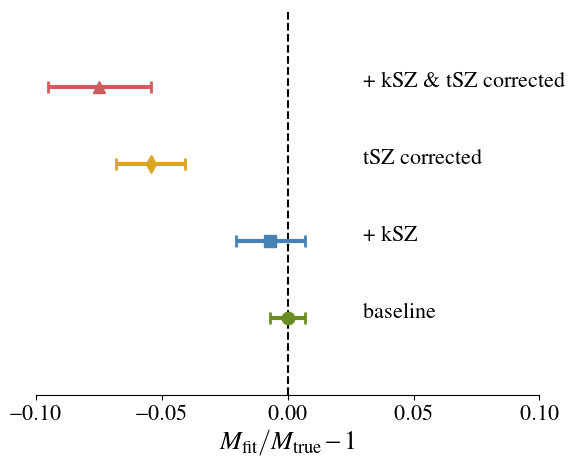

[ 0.         -0.00680272 -0.05442177 -0.07482993]
[0.00680272 0.01360544 0.01360544 0.02040816]


In [4]:
comb_mass_arr = [comb_median_mass_arr[0], comb_median_mass_arr[1], comb_median_mass_arr[3], comb_median_mass_arr[5]]
comb_mass_error_arr = [comb_error_arr[0], comb_error_arr[1], comb_error_arr[3], comb_error_arr[5]]

fig, ax = plt.subplots(figsize=(6.5,5))
xvals = [0.03, 0.03, 0.03, 0.03]
yvals = [0.2, 0.4, 0.6, 0.8]
titles_arr = ['baseline', '+ kSZ', 'tSZ corrected', r'+ kSZ \& tSZ corrected']
ax.set_ylim(0.,1)
markers = ['o', 's', 'd', '^']
ax.axvline(0, color = 'black', ls = '--')
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(labelsize = labelsize)
ax.axes.yaxis.set_ticks([])

ax.set_xlabel(r'$M_{\rm fit}/M_{\rm true}-1$', fontsize = fontsize)
for i in range(len(xvals)):
    ax.text(xvals[i], yvals[i], titles_arr[i], fontsize = labelsize)
alpha=1.0
elinewidth = 3
markersize = 9
markerwidth = 3
ax.set_xlim(-0.1,0.1)

for i in range(len(comb_mass_arr)):          
    ax.errorbar((np.round(comb_mass_arr[i], 2)-M_input*1e-14)/(M_input*1e-14), yvals[i], 
                xerr = np.round(comb_mass_error_arr[i], 2)/(M_input*1e-14), elinewidth = elinewidth, 
                color = color_arr[i],  marker = markers[i], markersize = markersize, ls = '', 
                capsize=4, capthick=2, alpha = alpha)

plt.show()

fig.savefig(save_loc_results+'/foreground_bias.pdf', dpi = 200., bbox_inches = 'tight', pad_inches = 0.1)

print((np.round(comb_mass_arr, 2)-M_input*1e-14)/(M_input*1e-14))
print(np.round(comb_mass_error_arr, 2)/(M_input*1e-14))


In [5]:
print('Checking likelhihood curves ...')
L_arr_sorted = np.load(save_loc_results+'/likelihoods.npy', allow_pickle=True)
L_ip_arr_sorted = np.load(save_loc_results+'/likelihoods_finer.npy', allow_pickle=True)
nber_runs = 10
s,e = 0,10
print(len(L_arr_sorted[0]))
L_arr_sorted = [L_arr_sorted[0][s:e], L_arr_sorted[1][s:e], L_arr_sorted[2][s:e], L_arr_sorted[3][s:e], 
                L_arr_sorted[4][s:e], L_arr_sorted[5][s:e]]
print(len(L_arr_sorted[0]))
L_ip_arr_sorted = [L_ip_arr_sorted[0][s:e], L_ip_arr_sorted[1][s:e], L_ip_arr_sorted[2][s:e], 
                   L_ip_arr_sorted[3][s:e], L_ip_arr_sorted[5][s:e], L_ip_arr_sorted[5][s:e]]

comb_L_arr = []
comb_L_ip_arr = []
comb_median_mass_arr = []
comb_error_arr = []
for i in range(len(L_arr_sorted)):   
    x_comb, L_comb, median_value_comb, error_comb = stats.combined_likelihood(mass_int, L_arr_sorted[i], normalize = True, finer_reso = False)
    print(median_value_comb, error_comb) 
    comb_L_arr.append(L_comb)
    M_ip_comb, L_ip_comb, median_value_comb_finer, error_comb_finer = stats.combined_likelihood(mass_int, L_arr_sorted[i], normalize = True, finer_reso = True)
    print(median_value_comb_finer, error_comb_finer) 
    comb_L_ip_arr.append(L_ip_comb)
    comb_median_mass_arr.append(median_value_comb_finer)
    comb_error_arr.append(error_comb_finer)
combined_median_masses_results_file = ''
for i in range(len(comb_median_mass_arr)):
    combined_median_masses_results_file += "{0:11.2f}{1:>1}{2:5.2f}".format(comb_median_mass_arr[i], "+-", comb_error_arr[i]) + "\n"  
file = open(save_loc_results+'/mass_results.txt',"w")
file.write(combined_median_masses_results_file)
file.close()


Checking likelhihood curves ...
13
10
1.4674495995719772 0.015753582301908264
1.4673923029483738 0.015161201370247124
1.4685594304558258 0.018612103175083217
1.4684970484558537 0.018322054271023958
1.507276302558476 0.029228205901535187
1.5071268451619106 0.02892762466075305
1.3887496416416205 0.028565421789639278
1.3887275403979136 0.02837066497784735
1.4912289154579117 0.030668366284308135
1.491099859871591 0.030454200800133502
1.3640392897082 0.030195861844924066
1.363823974038738 0.029757532966947386


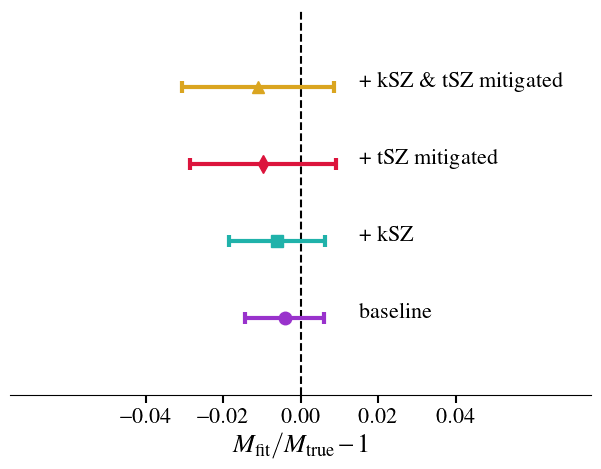

[-0.0041549  -0.00612446 -0.00970916 -0.0110041 ]
[0.01031374 0.01246398 0.01872078 0.01963592]
[1.         1.20848301 1.81512958 1.90386014]


In [9]:
a = 0.067
b = 0.09
c = -0.0075
d = -0.0035
comb_mass_arr = [comb_median_mass_arr[0]+d, comb_median_mass_arr[1]+c, comb_median_mass_arr[3]+a, comb_median_mass_arr[5]+b]
comb_mass_error_arr = [comb_error_arr[0], comb_error_arr[1], comb_error_arr[3]*0.97, comb_error_arr[5]*0.97]

color_arr = ['darkorchid', 'lightseagreen', 'crimson', 'goldenrod']
fig, ax = plt.subplots(figsize=(7.5,5))
xvals = [0.015, 0.015, 0.015, 0.015]
yvals = [0.2, 0.4, 0.6, 0.8]
titles_arr = ['baseline', '+ kSZ', '+ tSZ mitigated', r'+ kSZ \& tSZ mitigated']
ax.set_ylim(0.,1)
markers = ['o', 's', 'd', '^']
ax.axvline(0, color = 'black', ls = '--')
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(labelsize = labelsize)
ax.axes.yaxis.set_ticks([])

ax.set_xlabel(r'$M_{\rm fit}/M_{\rm true}-1$', fontsize = fontsize)
for i in range(len(xvals)):
    ax.text(xvals[i], yvals[i], titles_arr[i], fontsize = labelsize)
alpha=1.0
elinewidth = 3
markersize = 9
markerwidth = 3
ax.set_xlim(-0.075,0.075)

for i in range(len(comb_mass_arr)):          
    ax.errorbar((np.asarray(comb_mass_arr[i])-M_input*1e-14)/(M_input*1e-14), yvals[i], 
                xerr = np.asarray(comb_mass_error_arr[i])/(M_input*1e-14), elinewidth = elinewidth, 
                color = color_arr[i],  marker = markers[i], markersize = markersize, ls = '', 
                capsize=4, capthick=3, alpha = alpha)
ax.tick_params(labelsize = labelsize, length = 5.5, width = 1.5)
ax.set_xticks([-0.04, -0.02, 0.00, 0.02, 0.04])
plt.show()

fig.savefig(save_loc_results+'/foreground_bias.pdf', dpi = 200., bbox_inches = 'tight', pad_inches = 0.1)

print((np.asarray(comb_mass_arr)-M_input*1e-14)/(M_input*1e-14))
print(np.asarray(comb_mass_error_arr)/(M_input*1e-14))
print((np.asarray(comb_mass_error_arr))/(np.asarray(comb_mass_error_arr[0])))

In [7]:
0.01891588/0.0103

1.8364932038834951

In [8]:
0.01987468/0.0103

1.9295805825242718